# Stronghold Rosalind Solutions 

Here there are some solutions for some of the Rosalind Stronghold exercises

First of all, I would read some information stored in `./data` folder

In [1]:
import os
data_files = os.listdir("./data")
print(data_files)

['dna2rna_string.txt', 'dna_string.txt']


## Level 1: Simple and naive exercises

### Counting DNA Nucleotides

The very first basic problem is to count DNA nucleotides. Find additional information in the rosalind website link [here](https://rosalind.info/problems/dna/).

In [2]:
## read dna_string information as an example
with open("./data/dna_string.txt") as f:
  dna_string = f.read()

print("Information in dna_string is")
print(dna_string)

Information in dna_string is
AGCTTTTCATTCTGACTGCAACGGGCAATATGTCTCTGTGTGGATTAAAAAAAGAGTGTCTGATAGCAGC



Create a chunk of python code that given a string returns the counts for the nucleotides ('A', 'C', 'G', and 'T')

In [3]:
## solution 1
# Be easy
numA = dna_string.count("A")
print("A = " + str(numA))

numC = dna_string.count("C")
print("C = " + str(numC))

numG = dna_string.count("G")
print("G = " + str(numG))

numT = dna_string.count("T")
print("T = " + str(numT))

A = 20
C = 12
G = 17
T = 21


In [4]:
print(numA, numC, numG, numT)

20 12 17 21


Now, try to be more ellaborate and produce a more programmatic solution

In [5]:
## Solution 2
nucs=["A", "C", "G", "T"]
final_string = ""
for nuc in nucs:
    num_nuc = dna_string.count(nuc)
    print(nuc + " = " + str(num_nuc))
    final_string += str(num_nuc) + " "

print(final_string)


A = 20
C = 12
G = 17
T = 21
20 12 17 21 


Even more pythonic...

In [6]:
## Solution 3
nucs = ["A", "C", "G", "T"]
counts = [dna_string.count(nuc) for nuc in nucs]
final_string = " ".join(map(str, counts))
print(final_string)


20 12 17 21


Create a single file execution script from command line. See file in [`code/count_nuc.py`](./code/count_nuc.py)

### Transcribing DNA 

Following Rosalind problems, we will be translating DNA into RNA. Check additional details [here](https://rosalind.info/problems/rna/)

In [7]:
## read dna_string information as an example
with open("./data/dna2rna_string.txt") as f:
  dna2rna_string = f.read()

print("Information in dna2rna_string is")
print(dna2rna_string)

Information in dna2rna_string is
GATGGAACTTGACTACGTAAATT


In [8]:
# solution 1
## string format
dna2rna_string.replace("T", "U")

'GAUGGAACUUGACUACGUAAAUU'

A more bioinformatic approach...

In [9]:
# solution 2
from Bio.Seq import Seq
str(Seq(dna2rna_string).transcribe())

'GAUGGAACUUGACUACGUAAAUU'

Create a single command script from command line. See file in [`code/transcribe_nuc.py`](./code/transcribe_nuc.py)

### Reverse complement

Now, we will reverse complement the sequence. See details [here](https://rosalind.info/problems/revc/)

In [10]:
dna_seq = "AAAACCCGGT"

A manual ellaborate approach

In [11]:
# solution1
my_dict_nuc = {
    "A":"t",
    "C":"g",
    "T":"a",
    "G":"c"
}

## for each nucleotide replace in place using lowercase
for nuc in ["A", "C", "G", "T"]:
    dna_seq = dna_seq.replace(nuc, my_dict_nuc[nuc])
    #print(dna_seq)

# reverse and uppercase
print(dna_seq[::-1].upper())



ACCGGGTTTT


Again, a more bioinformatic approach...

In [12]:
# solution2
from Bio.Seq import Seq
print(str(Seq(dna_seq).reverse_complement()))

tggcccaaaa


Create a single script command line execution. See file in [`code/rev_com.py`](./code/rev_com.py)

## Level 2: More ellaborate exercises

Once the previous exercises have been solved, access to new and more ellaborate exercises is open such as: 
- “Rabbits and Recurrence Relations”, 
- “Computing GC Content”, 
- “Counting Point Mutations”, 
- “Mendel's First Law”, 
- “Translating RNA into Protein”, 
- “Finding a Motif in DNA”.

### Rabbits and recurrence relations


Find the official Rosalind problem [here](https://rosalind.info/problems/fib/) and a nice and easy explanation [here](https://medium.com/algorithms-for-life/rosalind-walkthrough-rabbits-and-recurrence-relations-4812c0c2ddb3
) for the Rabbits and recurrence problem.


The Fibonacci sequence starts with 0 and 1, with each number being the sum of the two before it. A very simple way to generate it in Python is with a loop:


In [13]:
n = 10
a, b = 0, 1

fibonacci_numbers = []

for _ in range(n):  
    fibonacci_numbers.append(str(a)) 
    a, b = b, a + b

print(' '.join(fibonacci_numbers))


0 1 1 2 3 5 8 13 21 34


See additional details and many more solutions in the datacamp site [here](https://www.datacamp.com/tutorial/fibonacci-sequence-python).

In the Rosalind problem, we have to take also into account that there is a delay in the number of rabbits mating, due to the reproduction-age limitation of 1 month and also, that they might produce more than 1 rabbit pair per generation. 

As an example, see the following illustration (source [here](https://medium.com/algorithms-for-life/rosalind-walkthrough-rabbits-and-recurrence-relations-4812c0c2ddb3)), where white bullets are young rabbits and black bullets are adult rabbits. The number of rabbits generated in each litter is 3 and the months simulated are 5.

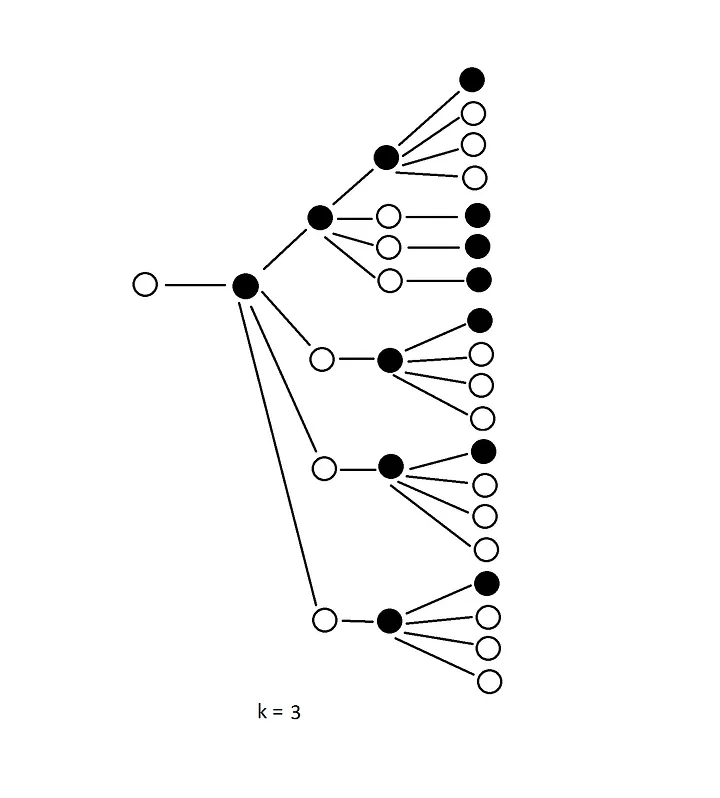

To solve this, we have to take into account both the delay and the number of offsprings.

In [14]:
starting_pairs = 1
num_offSpring = 3

## first month
total_n1 = starting_pairs
print("total month 1: "+ str(total_n1))

## second month
total_n2 = starting_pairs
print("total month 2: "+ str(total_n2))

## third month
total_n3 = starting_pairs + num_offSpring
print("total month 3: "+ str(total_n3))

## fourth month
total_n4 = total_n3 + total_n2*num_offSpring 
print("total month 4: "+ str(total_n4))

## fifth month
total_n5 = total_n4 + total_n3*num_offSpring 
print("total month 5: "+ str(total_n5))

## Sixth month
total_n6 = total_n5 + total_n4*num_offSpring 
print("total month 6: "+ str(total_n6))

total month 1: 1
total month 2: 1
total month 3: 4
total month 4: 7
total month 5: 19
total month 6: 40


The **total number of rabbits** in each generation is equal to the number of **adults** one generation back and the number of offspring born during each mating with the number of rabbits two generations ago. We simply add this to the number of rabbits one generation ago to get our answer.

We have a solution available [here](https://medium.com/algorithms-for-life/rosalind-walkthrough-rabbits-and-recurrence-relations-4812c0c2ddb3) that allows us to check whether the code we generated is ok.

In [15]:
## Truth
def rabbitPairs(numMonths, numOffspring):
    
    if (numMonths == 1):
        return 1
    elif (numMonths == 2):
        return numOffspring
    
    oneGen = rabbitPairs(numMonths - 1, numOffspring)
    twoGen = rabbitPairs(numMonths - 2, numOffspring)
    
    if (numMonths <= 4):
        return (oneGen + twoGen)
    
    return (oneGen + (twoGen * numOffspring))

In [16]:
rabbitPairs(29,3)

8878212019

In [17]:
def getRabbits(starting_pairs = 1, num_offSpring = 3, month_to_check=1):

    if month_to_check<3:
        return(starting_pairs)
    
    if month_to_check==3:
        return(starting_pairs + num_offSpring)

    if month_to_check>3:
        total_n1= getRabbits(starting_pairs, num_offSpring, month_to_check-1)
        total_n2= getRabbits(starting_pairs, num_offSpring, month_to_check-2)

        total_n = total_n1 + total_n2*num_offSpring 

        return(total_n)


In [18]:
rabbitPairs(4,3)

7

In [19]:
getRabbits(starting_pairs=1, num_offSpring=3, month_to_check=5)

19

In [20]:
rabbitPairs(6,3) == getRabbits(starting_pairs=1, num_offSpring=3, month_to_check=6)

True

Create a single file execution script from command line. See file in [`code/rabbit_count.py`](./code/rabbit_count.py)

### Mendel First Law


In this particular [exercise](https://rosalind.info/problems/iprb/), using combinations and probability, we will explore Mendel First Law of inheritance. 

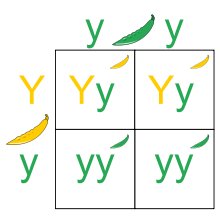

We are given a population containing k+m+n individuals where 
- k: individuals are homozygous dominant for a factor, 
- m: are heterozygous, and 
- n: are homozygous recessive.

and we need to return the probability that two randomly selected mating organisms will produce an individual possessing a dominant allele (and thus displaying the dominant phenotype)

In [21]:
## probabilities derived from Punnet matrix
genotypes = ['AA', 'Aa', 'aa']
prob_AA = [1,1,1]
prob_Aa = [1,0.75,0.5]
prob_aa = [1,0.5,0]

import numpy as np
x = np.array([prob_AA, prob_Aa, prob_aa])
x

array([[1.  , 1.  , 1.  ],
       [1.  , 0.75, 0.5 ],
       [1.  , 0.5 , 0.  ]])

In [22]:
# possible offspring with phenotype
x*4

array([[4., 4., 4.],
       [4., 3., 2.],
       [4., 2., 0.]])

In [23]:
# pip install scipy

I came with a solution as mixture of some other solution, from StackOverflow forum website [here](http://stackoverflow.com/questions/25119106/rosalind-mendels-first-law-iprb)

In [24]:
from scipy.special import comb

# k  = number of homozygous dominant organisms
k=2

# m  = number of homozygous recessive organisms
m=2

# n = number of heterozygous organisms
n=2

n_ind = k+m+n
print("Total individuals: ", n_ind)

# total population of alleles taken into account 
# 4 genotypes in each mating, and 2 individuals taken
pop_total = comb(n_ind, 2)
print("Total combinations of alleles: ", pop_total)
print("----------\n")

# dominant organisms         
## add the probability of each to produce dominant genotypes: AAxAA:1; AAxAa=1; AAxaa=1; AaxAa=3/4 Aaxaa= 2/4 and aaxaa:0/4
validCombos = 1*comb(k, 2) + 1*k*m + 1*k*n + .75*comb(m, 2) + .5*m*n + 0*comb(n, 2)

print("Dominant organisms: ", validCombos)

# probability for dominant organisms
phom = validCombos/pop_total
print("Dominant Probability: " + format(phom, ".2%"))
print("----------\n")

# Prob. dominant organisms + prob. recessive organisms equals 1
# let's check that:
rec_total = .5*n*m + .75*comb(m, 2) + .5*comb(n, 2) 
print("Recursive organisms: ", rec_total)

prec = rec_total/pop_total
print("Recursive Probability: " + format(prec, ".2%"))

print("----------\n")
if(1 - prec == phom):
    print("Prob. dominant organisms + prob. recessive organisms equals 1")
    print("Correct!")
    

Total individuals:  6
Total combinations of alleles:  15.0
----------

Dominant organisms:  11.75
Dominant Probability: 78.33%
----------

Recursive organisms:  3.25
Recursive Probability: 21.67%
----------

Prob. dominant organisms + prob. recessive organisms equals 1
Correct!


Create a single file execution script from command line. See file in [`code/mend_iprb.py`](./code/mend_iprb.py)

Here there is another solution, from StackOverflow forum website [here](http://stackoverflow.com/questions/25119106/rosalind-mendels-first-law-iprb)

In [25]:
def mendel(x, y, z):
    #calculate the probability of recessive traits only
    total = x+y+z
    twoRecess = (z/total)*((z-1)/(total-1))
    twoHetero = (y/total)*((y-1)/(total-1))
    heteroRecess = (z/total)*(y/(total-1)) + (y/total)*(z/(total-1))

    print("twoRecess:" + str(twoRecess))
    print("twoHetero:" + str(twoHetero))
    print("heteroRecess:" + str(heteroRecess))


    recessProb = twoRecess + twoHetero*1/4 + heteroRecess*1/2
    print(1-recessProb) # take the complement

mendel(2, 2, 2)

twoRecess:0.06666666666666667
twoHetero:0.06666666666666667
heteroRecess:0.26666666666666666
0.7833333333333333
